In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning and Pre-processing

In [2]:
ipl_data=pd.read_csv("All_Teams_IPL_Performance_Dataset.csv")
ipl_data['season'].unique()

array([2017, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016])

In [3]:
ipl_data.isnull().sum()

season                           0
venue                            0
team                             0
opponent                         0
toss_result                      0
team_total_runs                  0
opponent_total_runs              0
team_powerplay_runs              0
opponent_powerplay_runs          0
team_death_overs_runs            0
opponent_death_overs_runs        0
team_total_wickets_fallen        0
opponent_total_wickets_fallen    0
match_result                     0
dtype: int64

In [4]:
ipl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   season                         1272 non-null   int64 
 1   venue                          1272 non-null   object
 2   team                           1272 non-null   object
 3   opponent                       1272 non-null   object
 4   toss_result                    1272 non-null   int64 
 5   team_total_runs                1272 non-null   int64 
 6   opponent_total_runs            1272 non-null   int64 
 7   team_powerplay_runs            1272 non-null   int64 
 8   opponent_powerplay_runs        1272 non-null   int64 
 9   team_death_overs_runs          1272 non-null   int64 
 10  opponent_death_overs_runs      1272 non-null   int64 
 11  team_total_wickets_fallen      1272 non-null   int64 
 12  opponent_total_wickets_fallen  1272 non-null   int64 
 13  mat

In [5]:
def iqr_winsorization(df,thresh=1.5):
  
      
    columns_to_treat=df[['toss_result','team_total_runs','opponent_total_runs','team_powerplay_runs','opponent_powerplay_runs','team_death_overs_runs','opponent_death_overs_runs','team_total_wickets_fallen','opponent_total_wickets_fallen','match_result']]
    for col in columns_to_treat:
        # Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define fences
        lower_fence = Q1 - thresh * IQR
        upper_fence = Q3 + thresh * IQR

        # Winsorize outliers
        df.loc[df[col] < lower_fence, col] = lower_fence
        df.loc[df[col] > upper_fence, col] = upper_fence

    return df
iqr_winsorization(ipl_data, thresh=1.5)

C:\Users\mayur\AppData\Local\Temp\ipykernel_47972\1700770009.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower_fence, col] = lower_fence
C:\Users\mayur\AppData\Local\Temp\ipykernel_47972\1700770009.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower_fence, col] = lower_fence
C:\Users\mayur\AppData\Local\Temp\ipykernel_47972\1700770009.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower

,season,venue,team,opponent,toss_result,team_total_runs,opponent_total_runs,team_powerplay_runs,opponent_powerplay_runs,team_death_overs_runs,opponent_death_overs_runs,team_total_wickets_fallen,opponent_total_wickets_fallen,match_result
0,2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,0.0,207.0,172.0,59.0,54.0,56,33,4,10,1.0
1,2017,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,172.0,207.0,54.0,59.0,33,56,10,4,0.0
2,2017,Maharashtra Cricket Association Stadium,Mumbai Indians,Rising Pune Supergiant,0.0,184.0,187.0,61.0,59.0,64,48,8,3,0.0
3,2017,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,1.0,187.0,184.0,59.0,61.0,48,64,3,8,1.0
4,2017,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,0.0,183.0,184.0,52.0,73.0,58,0,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2016,Feroz Shah Kotla,Kolkata Knight Riders,Sunrisers Hyderabad,1.0,140.0,162.0,46.0,43.0,30,53,8,8,0.0
1268,2016,Feroz Shah Kotla,Gujarat Lions,Sunrisers Hyderabad,0.0,162.0,163.0,38.0,46.0,53,47,7,6,0.0
1269,2016,Feroz Shah Kotla,Sunrisers Hyderabad,Gujarat Lions,1.0,163.0,162.0,46.0,38.0,47,53,6,7,1.0
1270,2016,M Chinnaswamy Stadium,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,208.0,200.0,59.0,59.0,68,42,7,7,1.0


In [6]:
ipl_data['team']=ipl_data['team'].replace({'Rising Pune Supergiant':'Rising Pune Supergiants'})

In [7]:
ipl_data['run_difference']=ipl_data['team_total_runs']-ipl_data['opponent_total_runs']


In [8]:
ipl_data.to_csv("new_ipl_data.csv")

# Business Objective-1
# Identify the strongest performance indicators that lead to winning.

* Eda

In [9]:
bar_chart=ipl_data.groupby("match_result")[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs",
    "team_total_wickets_fallen"
]].mean()
bar_chart

,team_total_runs,team_powerplay_runs,team_death_overs_runs,team_total_wickets_fallen
match_result,,,,
0.0,145.982003,42.109155,40.514867,7.208138
1.0,160.274487,48.040679,41.565561,4.473934


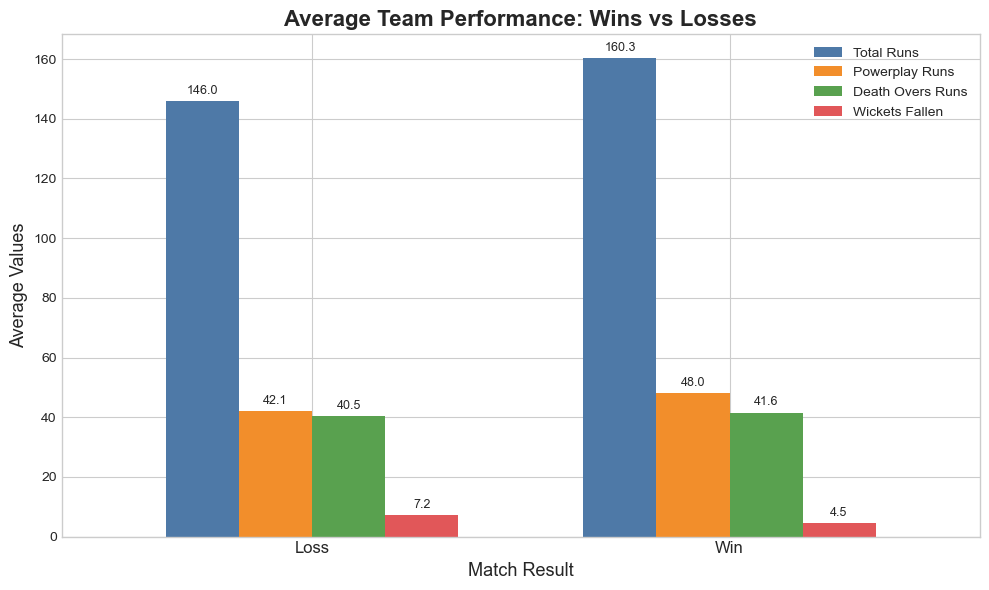

In [10]:
import matplotlib.pyplot as plt

bar_chart = ipl_data.groupby("match_result")[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs",
    "team_total_wickets_fallen"
]].mean()

# Convert index values to labels
bar_chart.index = ['Loss', 'Win']

plt.style.use("seaborn-v0_8-whitegrid")

ax = bar_chart.plot(
    kind="bar",
    figsize=(10,6),
    width=0.7,
    color=["#4E79A7","#F28E2B","#59A14F","#E15759"]
)

plt.title("Average Team Performance: Wins vs Losses", fontsize=16, weight="bold")
plt.xlabel("Match Result", fontsize=13)
plt.ylabel("Average Values", fontsize=13)

# Ensure labels appear clearly
plt.xticks(ticks=[0,1], labels=["Loss","Win"], rotation=0, fontsize=12)

plt.legend(
    ["Total Runs","Powerplay Runs","Death Overs Runs","Wickets Fallen"],
    frameon=False
)
# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)


plt.tight_layout()
plt.show()

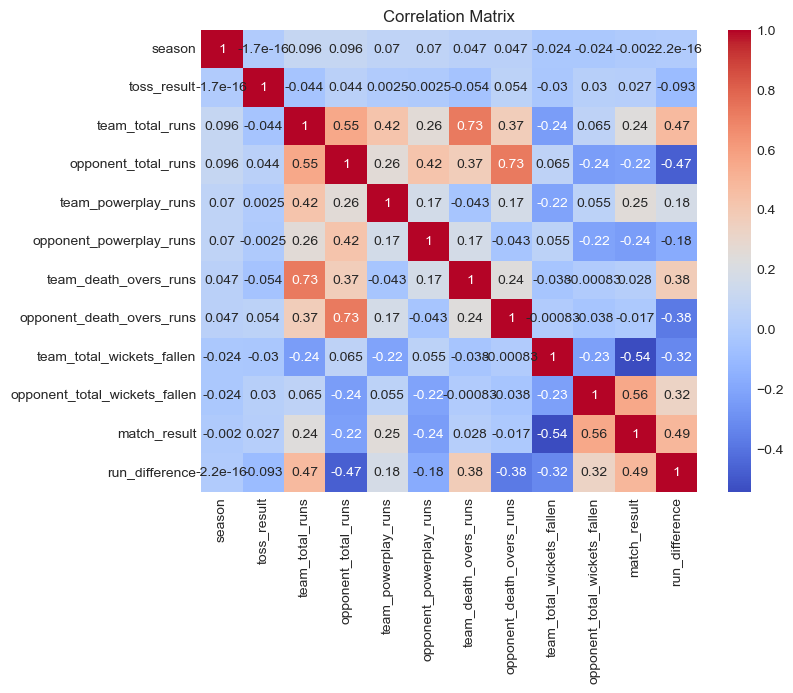

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(ipl_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
# Null hypothesis -Mean Total Runs during a win is equal to Mean Total Runs during a loss .
# Alternate hypothesis -Mean Total Runs during a win is not equal to Mean Total Runs during a loss.

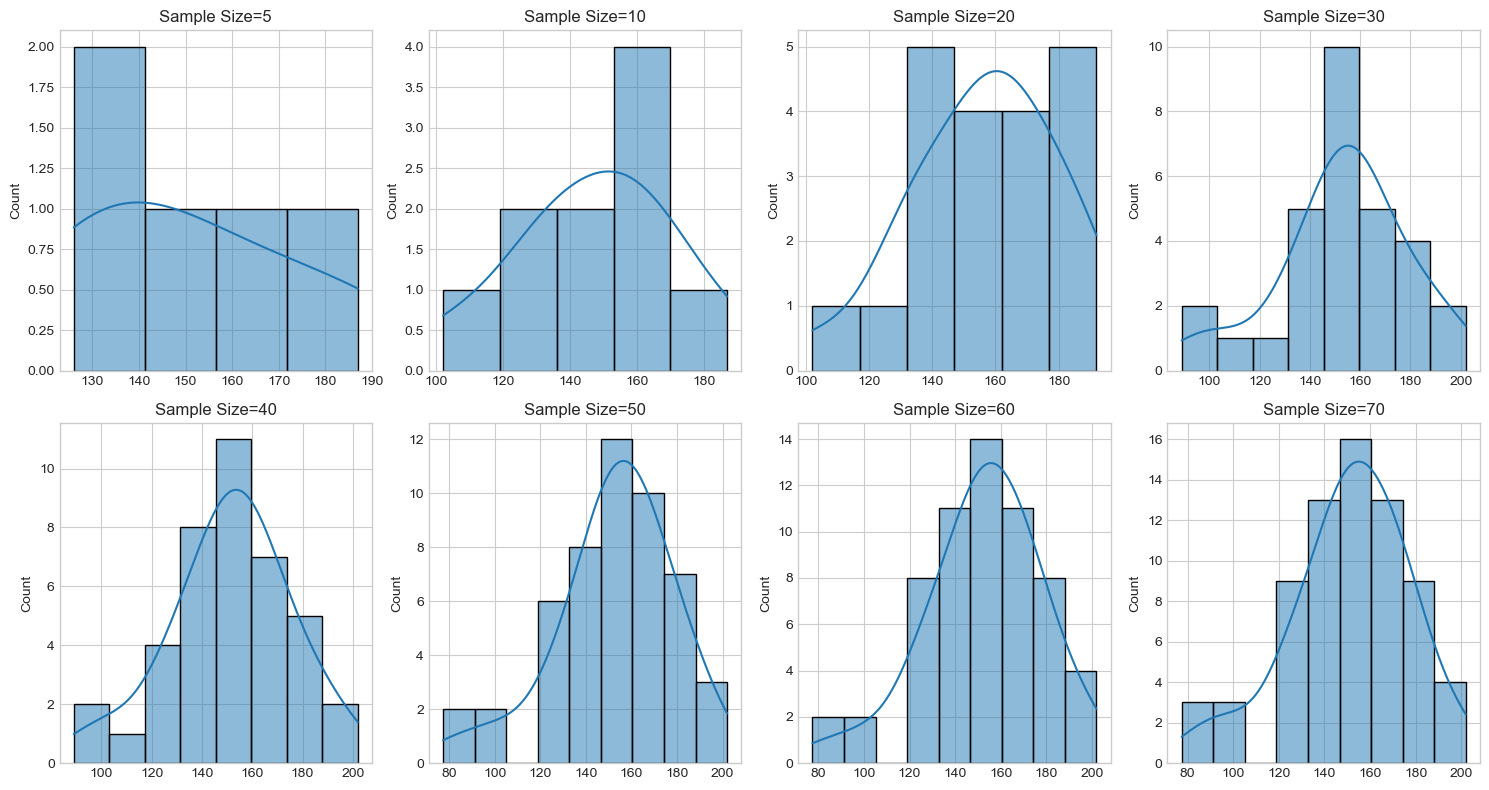

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# create population dataframe
population_df = ipl_data[['team_total_runs']].dropna()

num = [5,10,20,30,40,50,60,70,80,90,100]

data_s = []
data_s_mean = []

fig, ax = plt.subplots(2,4,figsize=(15,8))

k = 0

for i in num:
    sample_df = population_df.sample(n=i, random_state=1, replace=True)
    data_s.append(sample_df['team_total_runs'].tolist())
    data_s_mean.append(sample_df['team_total_runs'].mean())

k = 0
for i in range(2):
    for j in range(4):
        sns.histplot(data_s[k], kde=True, ax=ax[i,j])
        ax[i,j].set_title("Sample Size=" + str(len(data_s[k])))
        k += 1

plt.tight_layout()
plt.show()

In [14]:
sample_df = population_df.sample(n=30, random_state=1, replace=True)

print("-----Mean Value------")
print("Sample mean:", round(sample_df['team_total_runs'].mean(), 2))
print("Population mean:", round(population_df['team_total_runs'].mean(), 2))

print("-----Skewness------")
print("Sample Skewness:", round(sample_df['team_total_runs'].skew(), 2))
print("Population Skewness:", round(population_df['team_total_runs'].skew(), 2))

print("-----Kurtosis------")
print("Sample Kurtosis:", round(sample_df['team_total_runs'].kurtosis(), 2))
print("Population Kurtosis:", round(population_df['team_total_runs'].kurtosis(), 2))

-----Mean Value------
Sample mean: 153.0
Population mean: 153.09
-----Skewness------
Sample Skewness: -0.57
Population Skewness: -0.21
-----Kurtosis------
Sample Kurtosis: 0.62
Population Kurtosis: 0.01


In [15]:
sample_df=pd.DataFrame()
for i in range(0,10):
    sample_df["sample"+str(i)]=population_df['team_total_runs'].sample(n=30,random_state=i).reset_index(drop=True)
sample_df

,sample0,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9
0,141.0,138.0,189.0,153.000,151.000,150.000,166.0,118.000,230.375,132.000
1,183.0,132.0,141.0,128.000,145.000,142.000,176.0,187.000,178.000,177.000
2,186.0,118.0,119.0,139.000,120.000,118.000,128.0,187.000,184.000,178.000
3,208.0,155.0,131.0,230.375,170.000,139.000,140.0,182.000,77.375,143.000
4,218.0,164.0,158.0,154.000,187.000,188.000,131.0,171.000,136.000,143.000
5,139.0,156.0,158.0,178.000,197.000,195.000,149.0,160.000,171.000,150.000
6,160.0,102.0,102.0,127.000,127.000,163.000,191.0,141.000,136.000,191.000
7,120.0,141.0,142.0,97.000,154.000,159.000,170.0,139.000,181.000,142.000
8,149.0,157.0,178.0,155.000,135.000,77.375,160.0,164.000,190.000,191.000
9,184.0,99.0,112.0,169.000,126.000,135.000,163.0,169.000,142.000,122.000


In [16]:
c_names=sample_df.columns
c_mean=[]
for i in c_names:
    c_mean.append(sample_df[i].mean())
means=pd.DataFrame()
means.insert(0,"C_name",c_names)
means.insert(1,"mean",c_mean)
means

,C_name,mean
0,sample0,165.333333
1,sample1,150.466667
2,sample2,148.400000
3,sample3,153.645833
4,sample4,152.691667
5,sample5,143.870833
6,sample6,157.933333
7,sample7,153.770833
8,sample8,153.158333
9,sample9,156.112500


In [17]:
std=means['mean'].std()
std

5.72799560422102

In [18]:
import math 
population_df['team_total_runs'].std()/math.sqrt(30)

5.53232839841444

In [19]:
import numpy as np
import math
from scipy import stats

# 1. Create Population
wins_pop = ipl_data[ipl_data["match_result"] == 1]["team_total_runs"]
losses_pop = ipl_data[ipl_data["match_result"] == 0]["team_total_runs"]

# 2. Draw Sample (n = 30)
wins_sample = wins_pop.sample(n=30, random_state=42)
losses_sample = losses_pop.sample(n=30, random_state=42)

# 3. Sample Means
mean1 = wins_sample.mean()
mean2 = losses_sample.mean()

# 4. Population Standard Deviations
sd1 = wins_pop.std(ddof=0)
sd2 = losses_pop.std(ddof=0)

# Sample sizes
n1 = len(wins_sample)
n2 = len(losses_sample)

# 5. Z-Test
se = math.sqrt((sd1**2 / n1) + (sd2**2 / n2))
z_score = (mean1 - mean2) / se

p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
z_critical = stats.norm.ppf(1 - 0.05/2)

# 6. Output

print(f"Z Score: {z_score:.4f}")
print(f"Critical Z: ±{z_critical:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject H0")
    print("Conclusion: Mean runs differ between wins and losses.")
else:
    print("Result: Fail to Reject H0")
    print("Conclusion: No significant difference in runs.")

Z Score: 2.2671
Critical Z: ±1.9600
P-value: 0.0234
Result: Reject H0
Conclusion: Mean runs differ between wins and losses.


* Logistic Regression

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score
le = LabelEncoder()

numeric_ipl_data=ipl_data.select_dtypes(include=["int64",'float64'])
scaled_ipl_data=pd.DataFrame(StandardScaler().fit_transform(numeric_ipl_data.to_numpy()),columns=numeric_ipl_data.columns)

In [21]:
scaled_ipl_data

,season,toss_result,team_total_runs,opponent_total_runs,team_powerplay_runs,opponent_powerplay_runs,team_death_overs_runs,opponent_death_overs_runs,team_total_wickets_fallen,opponent_total_wickets_fallen,match_result,run_difference
0,1.627458,-1.0,1.779652,0.624151,1.178989,0.756081,0.798164,-0.428774,-0.734736,1.651436,1.004728,1.224024
1,1.627458,1.0,0.624151,1.779652,0.756081,1.178989,-0.428774,0.798164,1.651436,-0.734736,-0.995294,-1.224024
2,1.627458,-1.0,1.020323,1.119365,1.348152,1.178989,1.224924,0.371403,0.856045,-1.132431,-0.995294,-0.104916
3,1.627458,1.0,1.119365,1.020323,1.178989,1.348152,0.371403,1.224924,-1.132431,0.856045,1.004728,0.104916
4,1.627458,-1.0,0.987308,1.020323,0.586918,2.363131,0.904854,-2.189162,-0.734736,-2.325517,-0.995294,-0.034972
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,1.266557,1.0,-0.432307,0.294008,0.079428,-0.174316,-0.588809,0.638128,0.856045,0.856045,-0.995294,-0.769387
1268,1.266557,-1.0,0.294008,0.327022,-0.597224,0.079428,0.638128,0.318058,0.458350,0.060655,-0.995294,-0.034972
1269,1.266557,1.0,0.327022,0.294008,0.079428,-0.597224,0.318058,0.638128,0.060655,0.458350,1.004728,0.034972
1270,1.266557,1.0,1.812666,1.548551,1.178989,1.178989,1.438305,0.051332,0.458350,0.458350,1.004728,0.279777


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

X = scaled_ipl_data[[
    "team_total_runs",
    "opponent_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs",
    "team_total_wickets_fallen"
]]

y = ipl_data["match_result"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Classification report:\n",classification_report(y_test,pred))

Accuracy: 0.8743455497382199
Classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       191
         1.0       0.87      0.88      0.88       191

    accuracy                           0.87       382
   macro avg       0.87      0.87      0.87       382
weighted avg       0.87      0.87      0.87       382



In [23]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

importance.sort_values("Coefficient",ascending=False)

,Feature,Coefficient
0,team_total_runs,2.850976
2,team_powerplay_runs,0.401648
3,team_death_overs_runs,-0.456577
4,team_total_wickets_fallen,-1.321357
1,opponent_total_runs,-2.909669


# Business Objective-2
# Determine whether early aggression leads to higher win probability.

* Eda

In [24]:
ipl_data.groupby("match_result")["team_powerplay_runs"].mean()

match_result
0.0    42.109155
1.0    48.040679
Name: team_powerplay_runs, dtype: float64

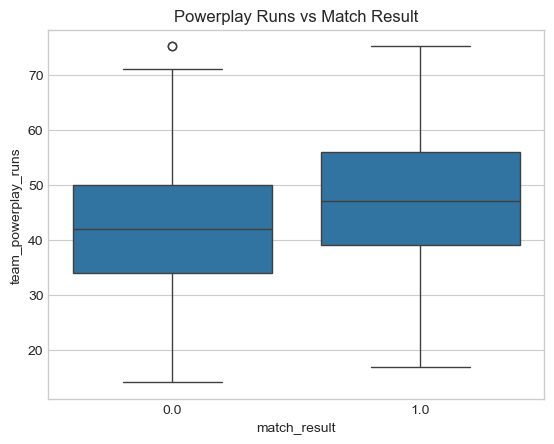

In [25]:
sns.boxplot(x="match_result", y="team_powerplay_runs", data=ipl_data)
plt.title("Powerplay Runs vs Match Result")
plt.show()

* Z-test

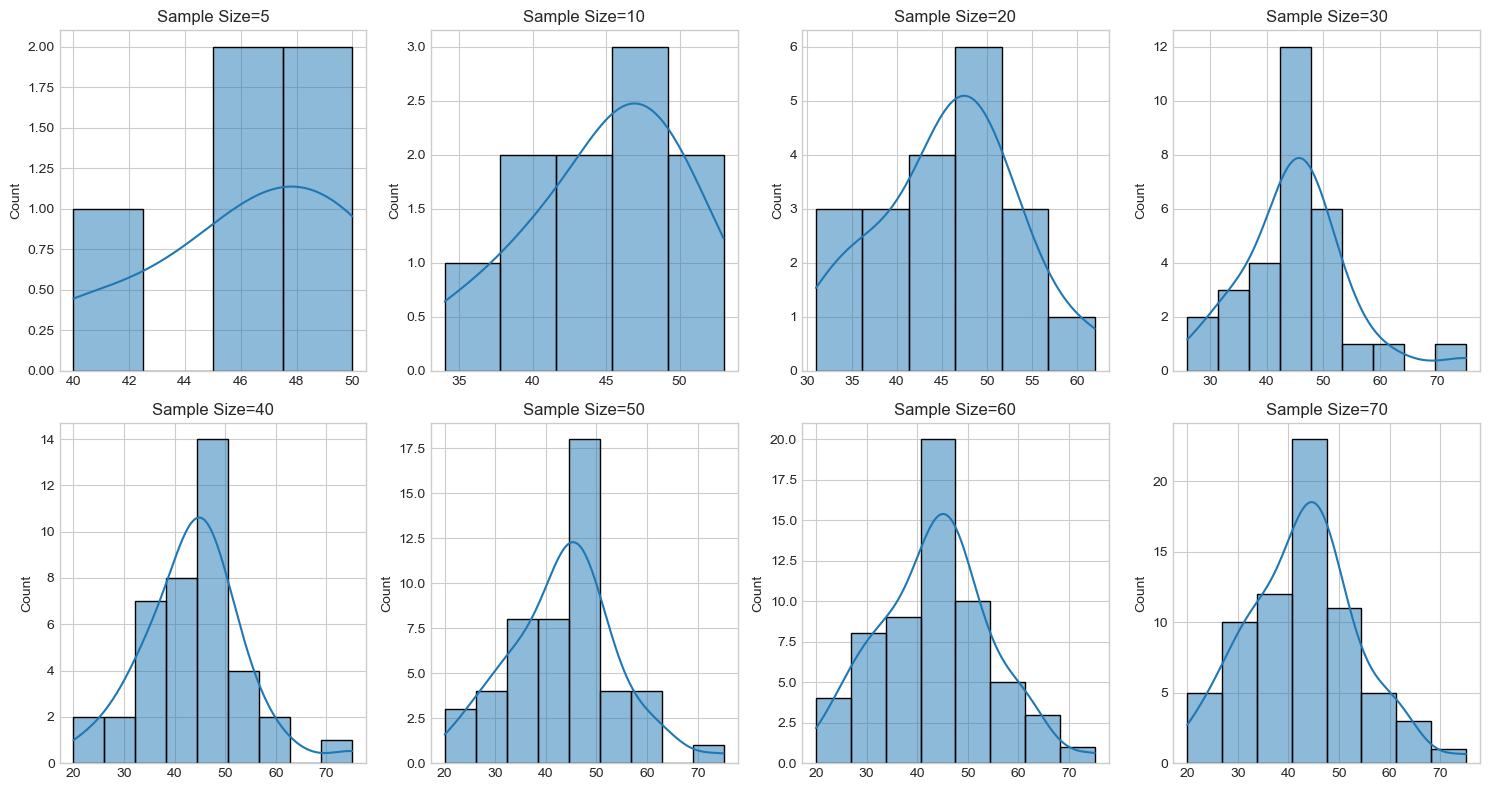

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# create population dataframe
population_df = ipl_data[['team_powerplay_runs']].dropna()

num = [5,10,20,30,40,50,60,70,80,90,100]

data_s = []
data_s_mean = []

fig, ax = plt.subplots(2,4,figsize=(15,8))

k = 0

for i in num:
    sample_df = population_df.sample(n=i, random_state=1, replace=True)
    data_s.append(sample_df['team_powerplay_runs'].tolist())
    data_s_mean.append(sample_df['team_powerplay_runs'].mean())

k = 0
for i in range(2):
    for j in range(4):
        sns.histplot(data_s[k], kde=True, ax=ax[i,j])
        ax[i,j].set_title("Sample Size=" + str(len(data_s[k])))
        k += 1

plt.tight_layout()
plt.show()

In [27]:
sample_df = population_df.sample(n=60, random_state=1, replace=True)

print("-----Mean Value------")
print("Sample mean:", round(sample_df['team_powerplay_runs'].mean(), 2))
print("Population mean:", round(population_df['team_powerplay_runs'].mean(), 2))

print("-----Skewness------")
print("Sample Skewness:", round(sample_df['team_powerplay_runs'].skew(), 2))
print("Population Skewness:", round(population_df['team_powerplay_runs'].skew(), 2))

print("-----Kurtosis------")
print("Sample Kurtosis:", round(sample_df['team_powerplay_runs'].kurtosis(), 2))
print("Population Kurtosis:", round(population_df['team_powerplay_runs'].kurtosis(), 2))

-----Mean Value------
Sample mean: 43.62
Population mean: 45.06
-----Skewness------
Sample Skewness: 0.2
Population Skewness: 0.2
-----Kurtosis------
Sample Kurtosis: 0.17
Population Kurtosis: -0.18


In [28]:
sample_df=pd.DataFrame()
for i in range(0,10):
    sample_df["sample"+str(i)]=population_df['team_powerplay_runs'].sample(n=30,random_state=i).reset_index(drop=True)
sample_df

,sample0,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9
0,65.0,39.0,59.0,50.000,53.000,62.0,36.000,33.0,39.0,45.0
1,45.0,23.0,37.0,58.000,30.000,36.0,60.000,30.0,61.0,62.0
2,32.0,29.0,37.0,43.000,38.000,27.0,75.125,50.0,39.0,50.0
3,39.0,55.0,50.0,30.000,43.000,29.0,59.000,56.0,39.0,48.0
4,67.0,46.0,36.0,75.125,46.000,72.0,45.000,40.0,47.0,46.0
5,32.0,50.0,44.0,50.000,62.000,46.0,35.000,45.0,40.0,43.0
6,64.0,29.0,40.0,33.000,53.000,46.0,58.000,47.0,61.0,34.0
7,25.0,40.0,39.0,46.000,61.000,61.0,50.000,37.0,41.0,45.0
8,44.0,37.0,52.0,60.000,57.000,32.0,38.000,37.0,54.0,63.0
9,51.0,50.0,26.0,41.000,41.000,24.0,50.000,41.0,60.0,42.0


In [29]:
c_names=sample_df.columns
c_mean=[]
for i in c_names:
    c_mean.append(sample_df[i].mean())
means=pd.DataFrame()
means.insert(0,"C_name",c_names)
means.insert(1,"mean",c_mean)
means

,C_name,mean
0,sample0,49.466667
1,sample1,41.300000
2,sample2,42.366667
3,sample3,47.137500
4,sample4,45.770833
5,sample5,46.166667
6,sample6,46.904167
7,sample7,45.500000
8,sample8,46.966667
9,sample9,45.633333


In [30]:
std=means['mean'].std()
std

2.3580236758489517

In [31]:
import math 
population_df['team_powerplay_runs'].std()/math.sqrt(30)

2.1594065694935822

In [32]:
# Null hypothesis-Average Powerplay score <= 45
# Alternate hypothesis-Average Powerplay score >45

In [33]:
import numpy as np
import math
from scipy import stats

# Benchmark
benchmark = 45

# 1. Create Population
pop = ipl_data["team_powerplay_runs"]

# 2. Draw Sample (n = 30)
sample = pop.sample(n=30, random_state=42)

# 3. Sample Mean
sample_mean = sample.mean()

# 4. Population Standard Deviation (for Z-test)
pop_std = pop.std()

# Sample size
n = len(sample)

# 5. Z-test (Right-tailed: mean > 45)
z_score = (sample_mean - benchmark) / (pop_std / math.sqrt(n))
p_value = 1 - stats.norm.cdf(z_score)

# Critical value (alpha = 0.05)
z_critical = stats.norm.ppf(1 - 0.05)

# 6. Output
print("===== Z-TEST (Right-tailed) =====")
print(f"Sample Mean: {sample_mean:.4f}")
print(f"Z-statistic: {z_score:.4f}")
print(f"Critical Z: {z_critical:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0")
    print("Average Powerplay score is significantly greater than 45")
else:
    print("\nConclusion: Fail to Reject H0")
    print("No significant evidence that average Powerplay score > 45")

===== Z-TEST (Right-tailed) =====
Sample Mean: 45.1708
Z-statistic: 0.0791
Critical Z: 1.6449
P-value: 0.4685

Conclusion: Fail to Reject H0
No significant evidence that average Powerplay score > 45


* Linear regression

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = scaled_ipl_data[["team_powerplay_runs"]]
y = scaled_ipl_data["team_total_runs"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

print("R2 score:", r2_score(y, pred))

R2 score: 0.18009934442073794


* Logistic Regression

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = scaled_ipl_data[["team_powerplay_runs"]]
y = ipl_data["match_result"]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5942408376963351


# Business Objective
# Toss result influence on match result.


* Eda

In [36]:
ipl_data.groupby("toss_result")["match_result"].mean()

toss_result
0.0    0.484277
1.0    0.511006
Name: match_result, dtype: float64

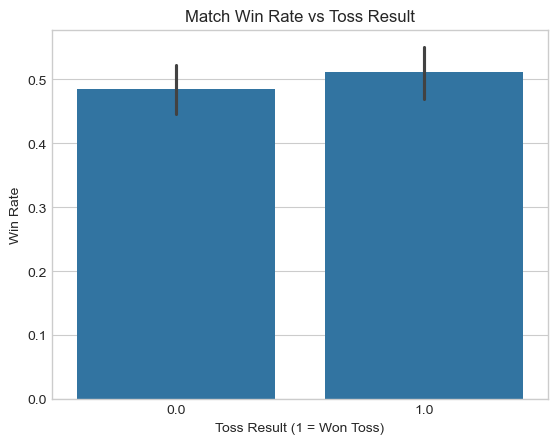

In [37]:
sns.barplot(x="toss_result", y="match_result", data=ipl_data)
plt.title("Match Win Rate vs Toss Result")
plt.xlabel("Toss Result (1 = Won Toss)")
plt.ylabel("Win Rate")
plt.show()

* Chi-Square Test
* Test independence between toss_result & match_result



In [38]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    ipl_data["toss_result"],
    ipl_data["match_result"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)
if p < 0.05:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion:Toss result significantly affect match outcome.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis.")
    print("Conclusion:Toss result Does not  affect match outcome.")

Chi-square: 0.805049358817465
p-value: 0.3695879691432319

Result: Fail to Reject the Null Hypothesis.
Conclusion:Toss result Does not  affect match outcome.


* Logistic Regression

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = ipl_data[["toss_result"]]
y = ipl_data["match_result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5


# Business Objective
# Influence of venue on team petrformance.

* Eda

In [40]:
venue_runs = ipl_data.groupby("venue")["team_total_runs"].mean().sort_values(ascending=False)
venue_runs

venue
Brabourne Stadium                                       174.636364
Saurashtra Cricket Association Stadium                  166.650000
Barabati Stadium                                        162.669643
Green Park                                              162.250000
Punjab Cricket Association IS Bindra Stadium, Mohali    162.034091
Himachal Pradesh Cricket Association Stadium            160.854167
MA Chidambaram Stadium, Chepauk                         158.972656
Maharashtra Cricket Association Stadium                 158.879167
Wankhede Stadium                                        157.948465
Holkar Cricket Stadium                                  157.600000
Sardar Patel Stadium, Motera                            156.958333
Punjab Cricket Association Stadium, Mohali              156.819643
M Chinnaswamy Stadium                                   156.771780
Feroz Shah Kotla                                        154.698958
Sharjah Cricket Stadium                                 

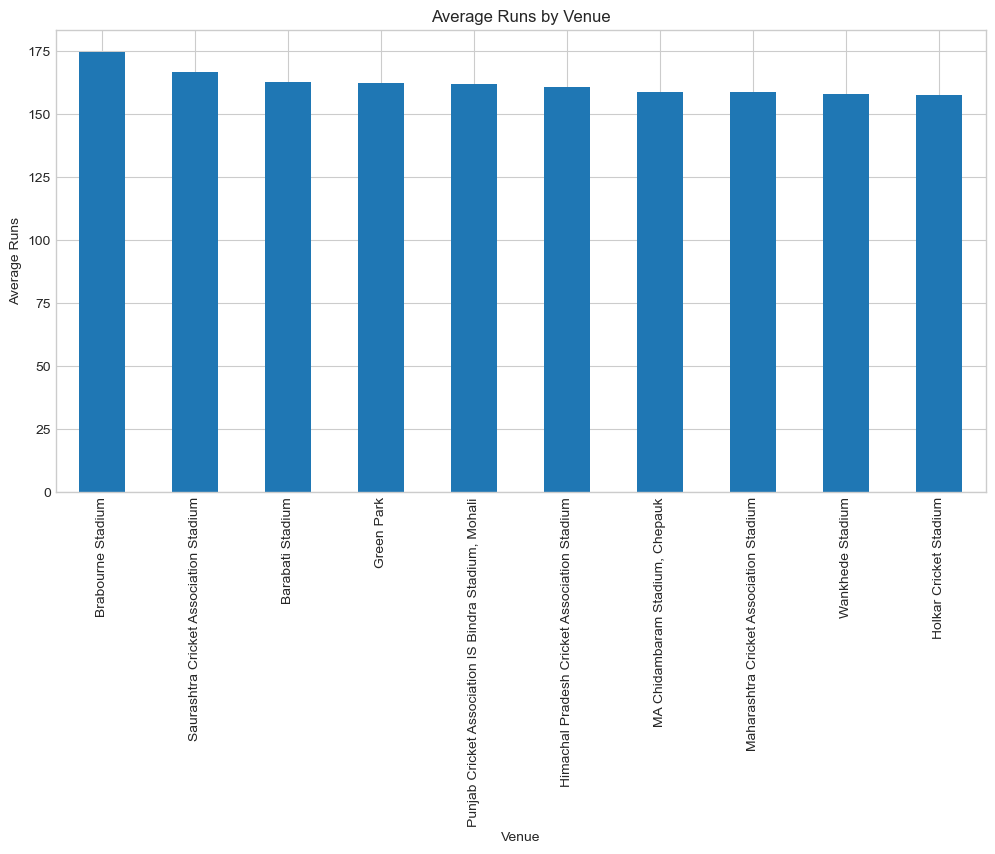

In [41]:
plt.figure(figsize=(12,6))
venue_runs.head(10).plot(kind="bar")

plt.title("Average Runs by Venue")
plt.ylabel("Average Runs")
plt.xlabel("Venue")
plt.show()

* ANOVA / T-test

In [42]:
#H0: Mean runs are the same across venues
#H1: Mean runs differ across venues

In [43]:
from scipy.stats import f_oneway

groups = [group["team_total_runs"].values for name, group in ipl_data.groupby("venue")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)
if p_value < 0.05:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion:Mean runs differ across venues.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis.")
    print("Conclusion: Mean runs are the same across venues")

F-statistic: 2.2610277166229085
p-value: 5.461262804649865e-05

Result: Reject the Null Hypothesis.
Conclusion:Mean runs differ across venues.



* Logistic regression

In [44]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder
le=LabelEncoder()
# Encode labels and column purpose_encode
ipl_data['venue_encode']=le.fit_transform(ipl_data['venue'])


In [45]:
def run_category(runs):
    if runs < 150:
        return 0   # Low
    elif runs <= 180:
        return 1   # Medium
    else:
        return 2   # High

ipl_data["run_category"] = ipl_data["team_total_runs"].apply(run_category)

In [46]:
ipl_data

,season,venue,team,opponent,toss_result,team_total_runs,opponent_total_runs,team_powerplay_runs,opponent_powerplay_runs,team_death_overs_runs,opponent_death_overs_runs,team_total_wickets_fallen,opponent_total_wickets_fallen,match_result,run_difference,venue_encode,run_category
0,2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,0.0,207.0,172.0,59.0,54.0,56,33,4,10,1.0,35.0,23,2
1,2017,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bangalore,Sunrisers Hyderabad,1.0,172.0,207.0,54.0,59.0,33,56,10,4,0.0,-35.0,23,1
2,2017,Maharashtra Cricket Association Stadium,Mumbai Indians,Rising Pune Supergiant,0.0,184.0,187.0,61.0,59.0,64,48,8,3,0.0,-3.0,16,2
3,2017,Maharashtra Cricket Association Stadium,Rising Pune Supergiants,Mumbai Indians,1.0,187.0,184.0,59.0,61.0,48,64,3,8,1.0,3.0,16,2
4,2017,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,0.0,183.0,184.0,52.0,73.0,58,0,4,0,0.0,-1.0,25,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2016,Feroz Shah Kotla,Kolkata Knight Riders,Sunrisers Hyderabad,1.0,140.0,162.0,46.0,43.0,30,53,8,8,0.0,-22.0,8,0
1268,2016,Feroz Shah Kotla,Gujarat Lions,Sunrisers Hyderabad,0.0,162.0,163.0,38.0,46.0,53,47,7,6,0.0,-1.0,8,1
1269,2016,Feroz Shah Kotla,Sunrisers Hyderabad,Gujarat Lions,1.0,163.0,162.0,46.0,38.0,47,53,6,7,1.0,1.0,8,1
1270,2016,M Chinnaswamy Stadium,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,208.0,200.0,59.0,59.0,68,42,7,7,1.0,8.0,14,2


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = ipl_data[["venue_encode"]]
y = ipl_data["run_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.4293193717277487


* Kmeans cluster

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

venue_stats = ipl_data.groupby("venue")[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs"
]].mean()

scaler = StandardScaler()

scaled = scaler.fit_transform(venue_stats)

kmeans = KMeans(n_clusters=2, random_state=42)

venue_stats["cluster"] = kmeans.fit_predict(scaled)

venue_stats

C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,team_total_runs,team_powerplay_runs,team_death_overs_runs,cluster
venue,,,,
Barabati Stadium,162.669643,43.571429,49.500000,0
Brabourne Stadium,174.636364,51.863636,51.454545,0
Buffalo Park,133.166667,39.500000,39.166667,1
De Beers Diamond Oval,149.500000,40.000000,46.500000,1
Dr DY Patil Sports Academy,141.470588,42.323529,36.647059,1
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,141.926136,39.681818,39.545455,1
Dubai International Cricket Stadium,147.428571,41.571429,41.642857,1
Eden Gardens,149.184426,45.017418,38.008197,1
Feroz Shah Kotla,154.698958,46.817708,39.191667,0


C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

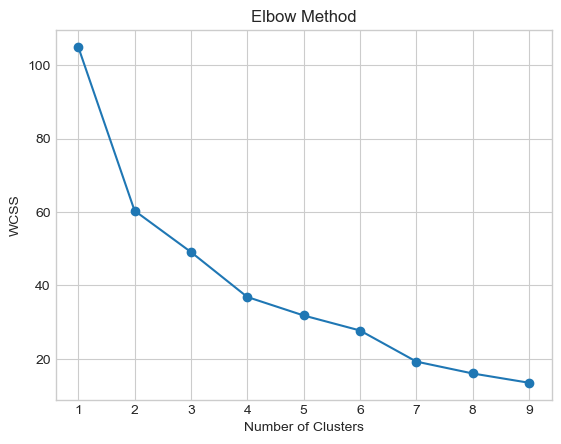

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

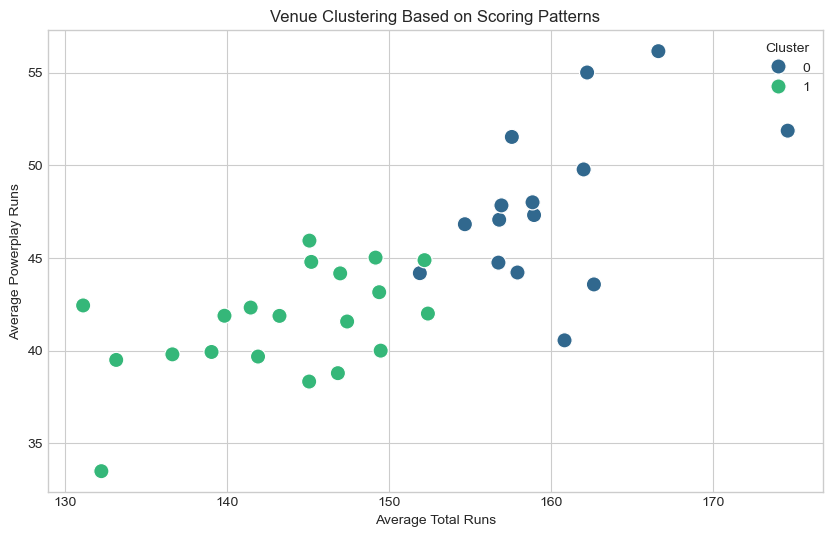

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=venue_stats["team_total_runs"],
    y=venue_stats["team_powerplay_runs"],
    hue=venue_stats["cluster"],
    palette="viridis",
    s=120
)

plt.xlabel("Average Total Runs")
plt.ylabel("Average Powerplay Runs")
plt.title("Venue Clustering Based on Scoring Patterns")
plt.legend(title="Cluster")
plt.show()

In [51]:
venue_stats.groupby("cluster").mean()

,team_total_runs,team_powerplay_runs,team_death_overs_runs
cluster,,,
0,159.977442,47.906810,42.520412
1,143.406713,41.477705,39.055680


In [52]:
cluster_labels = {
    0: "High Scoring Venues",
    1: "Moderate Scoring Venues",
    
}

venue_stats["cluster_type"] = venue_stats["cluster"].map(cluster_labels)

venue_stats.head()

,team_total_runs,team_powerplay_runs,team_death_overs_runs,cluster,cluster_type
venue,,,,,
Barabati Stadium,162.669643,43.571429,49.500000,0,High Scoring Venues
Brabourne Stadium,174.636364,51.863636,51.454545,0,High Scoring Venues
Buffalo Park,133.166667,39.500000,39.166667,1,Moderate Scoring Venues
De Beers Diamond Oval,149.500000,40.000000,46.500000,1,Moderate Scoring Venues
Dr DY Patil Sports Academy,141.470588,42.323529,36.647059,1,Moderate Scoring Venues


In [53]:
venue_stats['cluster_type'].value_counts()

cluster_type
Moderate Scoring Venues    20
High Scoring Venues        15
Name: count, dtype: int64

# Business Objective
# Identify high-performing and weak franchises.


* Eda

In [54]:
team_stats = ipl_data.groupby("team")[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs",
    "match_result"
]].mean()

team_stats

,team_total_runs,team_powerplay_runs,team_death_overs_runs,match_result
team,,,,
Chennai Super Kings,159.512405,45.658397,45.229008,0.603053
Deccan Chargers,152.840000,45.441667,41.773333,0.386667
Delhi Daredevils,149.761054,45.340136,38.136054,0.421769
Gujarat Lions,162.066667,51.966667,38.633333,0.433333
Kings XI Punjab,155.942568,46.218750,40.763514,0.472973
Kochi Tuskers Kerala,136.026786,47.723214,27.857143,0.428571
Kolkata Knight Riders,148.868243,45.434122,38.162162,0.520270
Mumbai Indians,156.244427,44.179936,45.203822,0.585987
Pune Warriors,139.899457,41.502717,37.673913,0.260870


<Axes: xlabel='team'>

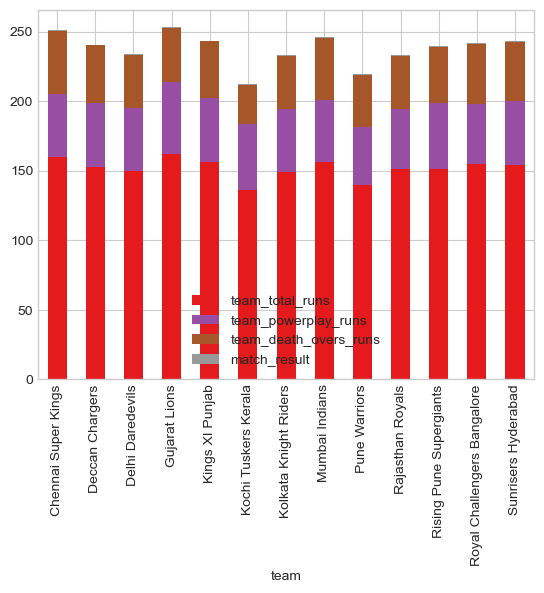

In [55]:
team_stats.plot(kind='bar',stacked=True,colormap='Set1')

In [56]:
team_stats["win_percentage"] = team_stats["match_result"] * 100

team_stats

,team_total_runs,team_powerplay_runs,team_death_overs_runs,match_result,win_percentage
team,,,,,
Chennai Super Kings,159.512405,45.658397,45.229008,0.603053,60.305344
Deccan Chargers,152.840000,45.441667,41.773333,0.386667,38.666667
Delhi Daredevils,149.761054,45.340136,38.136054,0.421769,42.176871
Gujarat Lions,162.066667,51.966667,38.633333,0.433333,43.333333
Kings XI Punjab,155.942568,46.218750,40.763514,0.472973,47.297297
Kochi Tuskers Kerala,136.026786,47.723214,27.857143,0.428571,42.857143
Kolkata Knight Riders,148.868243,45.434122,38.162162,0.520270,52.027027
Mumbai Indians,156.244427,44.179936,45.203822,0.585987,58.598726
Pune Warriors,139.899457,41.502717,37.673913,0.260870,26.086957


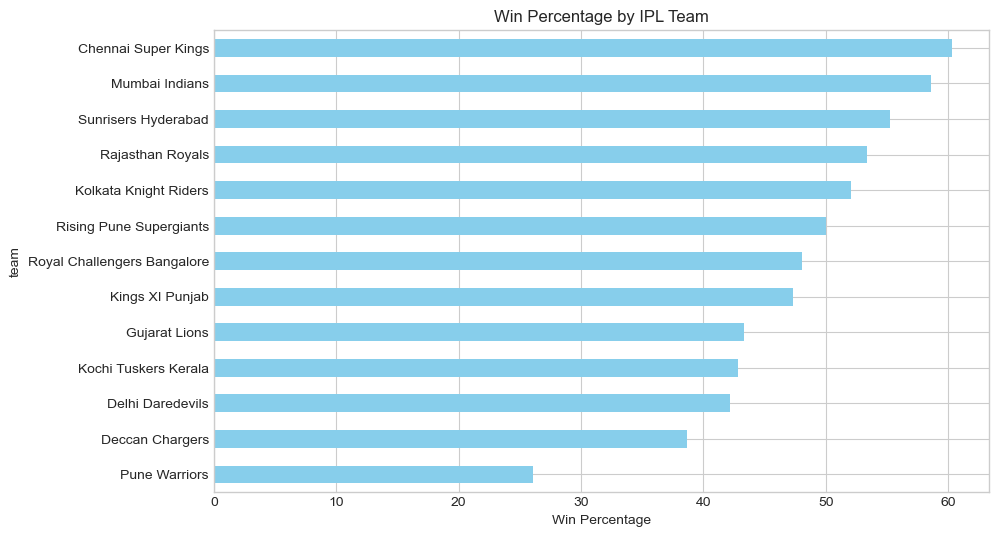

In [57]:

team_stats["win_percentage"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="skyblue"
)

plt.title("Win Percentage by IPL Team")
plt.xlabel("Win Percentage")
plt.show()

* Kmeans cluster

In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = team_stats[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs",
    "win_percentage"
]]

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)

team_stats["cluster"] = kmeans.fit_predict(scaled)

team_stats

C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,team_total_runs,team_powerplay_runs,team_death_overs_runs,match_result,win_percentage,cluster
team,,,,,,
Chennai Super Kings,159.512405,45.658397,45.229008,0.603053,60.305344,0
Deccan Chargers,152.840000,45.441667,41.773333,0.386667,38.666667,0
Delhi Daredevils,149.761054,45.340136,38.136054,0.421769,42.176871,0
Gujarat Lions,162.066667,51.966667,38.633333,0.433333,43.333333,0
Kings XI Punjab,155.942568,46.218750,40.763514,0.472973,47.297297,0
Kochi Tuskers Kerala,136.026786,47.723214,27.857143,0.428571,42.857143,1
Kolkata Knight Riders,148.868243,45.434122,38.162162,0.520270,52.027027,0
Mumbai Indians,156.244427,44.179936,45.203822,0.585987,58.598726,0
Pune Warriors,139.899457,41.502717,37.673913,0.260870,26.086957,1


C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mayur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

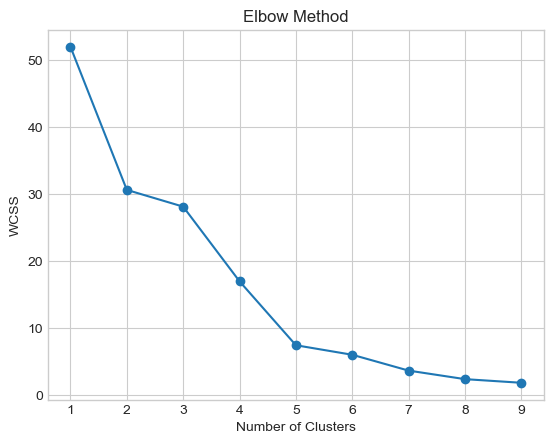

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

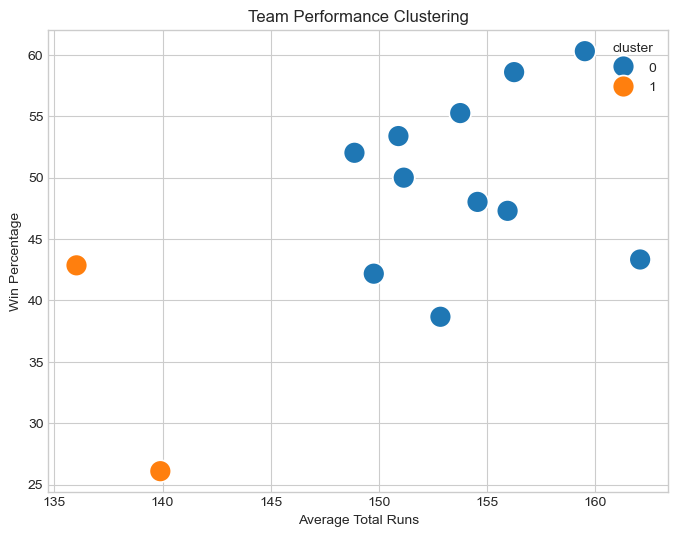

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=team_stats["team_total_runs"],
    y=team_stats["win_percentage"],
    hue=team_stats["cluster"],
    palette="tab10",
    s=250
)

plt.xlabel("Average Total Runs")
plt.ylabel("Win Percentage")

plt.title("Team Performance Clustering")

plt.show()

In [66]:
team_stats.groupby("cluster").mean().sort_values(by='win_percentage',ascending=False)

,team_total_runs,team_powerplay_runs,team_death_overs_runs,match_result,win_percentage
cluster,,,,,
0,154.144525,45.847524,41.089768,0.499168,49.916779
1,137.963121,44.612966,32.765528,0.344720,34.472050


In [68]:
cluster_labels = {
    0: "High scoring teams ",
    1: "low performing teams"
    
}

team_stats["cluster_type"] = team_stats["cluster"].map(cluster_labels)

team_stats

,team_total_runs,team_powerplay_runs,team_death_overs_runs,match_result,win_percentage,cluster,cluster_type
team,,,,,,,
Chennai Super Kings,159.512405,45.658397,45.229008,0.603053,60.305344,0,High scoring teams
Deccan Chargers,152.840000,45.441667,41.773333,0.386667,38.666667,0,High scoring teams
Delhi Daredevils,149.761054,45.340136,38.136054,0.421769,42.176871,0,High scoring teams
Gujarat Lions,162.066667,51.966667,38.633333,0.433333,43.333333,0,High scoring teams
Kings XI Punjab,155.942568,46.218750,40.763514,0.472973,47.297297,0,High scoring teams
Kochi Tuskers Kerala,136.026786,47.723214,27.857143,0.428571,42.857143,1,low performing teams
Kolkata Knight Riders,148.868243,45.434122,38.162162,0.520270,52.027027,0,High scoring teams
Mumbai Indians,156.244427,44.179936,45.203822,0.585987,58.598726,0,High scoring teams
Pune Warriors,139.899457,41.502717,37.673913,0.260870,26.086957,1,low performing teams


In [70]:
le = LabelEncoder()

numeric_team_stats=team_stats.select_dtypes(include=["int64",'float64'])
scaled_team_stats=pd.DataFrame(StandardScaler().fit_transform(numeric_team_stats.to_numpy()),columns=numeric_team_stats.columns)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = scaled_team_stats[[
    "team_total_runs",
    "team_powerplay_runs",
    "team_death_overs_runs"
]]

y = scaled_team_stats["win_percentage"]

model = LinearRegression()

model.fit(X,y)

pred = model.predict(X)

print("R2 Score:", r2_score(y,pred))

R2 Score: 0.30481787013929484


# Business Objective-6
# Identify scoring drivers

* Eda

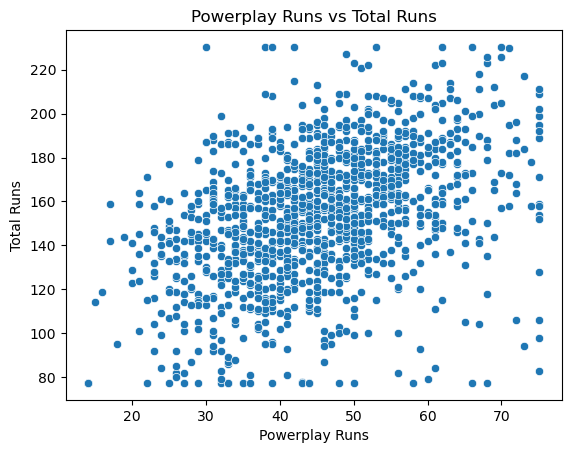

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=ipl_data["team_powerplay_runs"],
    y=ipl_data["team_total_runs"]
)

plt.title("Powerplay Runs vs Total Runs")
plt.xlabel("Powerplay Runs")
plt.ylabel("Total Runs")

plt.show()

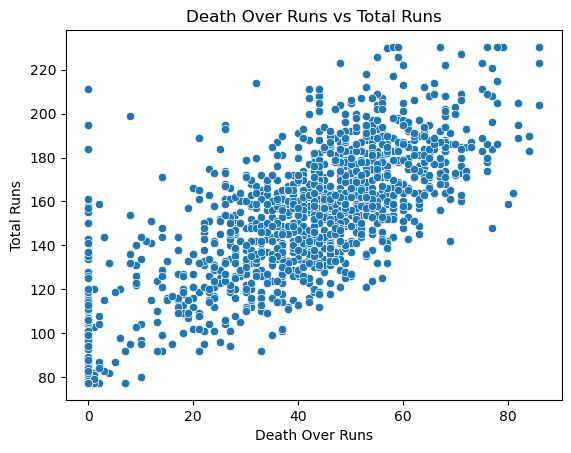

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=ipl_data["team_death_overs_runs"],
    y=ipl_data["team_total_runs"]
)

plt.title("Death Over Runs vs Total Runs")
plt.xlabel("Death Over Runs")
plt.ylabel("Total Runs")

plt.show()

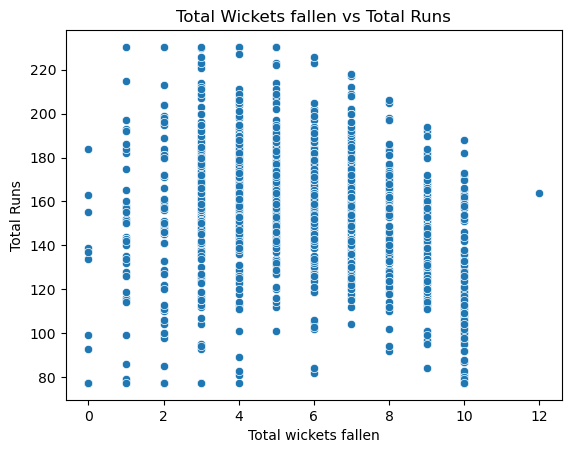

In [56]:
sns.scatterplot(
    x=ipl_data["team_total_wickets_fallen"],
    y=ipl_data["team_total_runs"]
)

plt.title("Total Wickets fallen vs Total Runs")
plt.xlabel("Total wickets fallen")
plt.ylabel("Total Runs")

plt.show()

* Multiple linear regression

In [72]:
X = scaled_ipl_data[[
    "team_powerplay_runs",
    "team_death_overs_runs",
    "team_total_wickets_fallen"
]]

y = scaled_ipl_data["team_total_runs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.7509109473145597


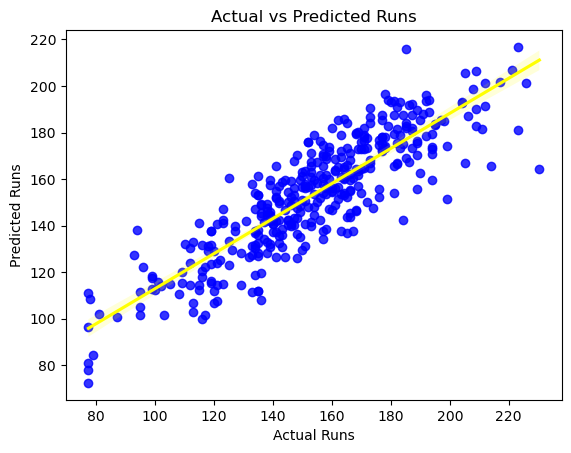

In [58]:
sns.regplot(x=y_test,y= pred,color='blue',line_kws={'color':"yellow"})

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")

plt.title("Actual vs Predicted Runs")

plt.show()